In [101]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Patch for NumPy 2.0 compatibility
if not hasattr(np, 'matrix'):
    np.matrix = np.array

In [102]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")

In [103]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [104]:
orders.info()
orders.describe()
orders.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [ ]:
cols=["order_purchase_timestamp", 
"order_approved_at",
"order_delivered_carrier_date",
"order_delivered_customer_date",
"order_estimated_delivery_date"]
orders[cols] = orders[cols].apply(lambda col: pd.to_datetime(col, errors = 'coerce')) # errors = 'coerce' will handle null values

In [106]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [107]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [108]:
print(customers.isna().sum())
print(orders.isna().sum())
print(payments.isna().sum())

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [109]:
df = customers.merge(orders, how='left', on='customer_id')\
.merge(payments, how='left', on='order_id')

In [110]:
df.head(1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103887 entries, 0 to 103886
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    103887 non-null  object        
 1   customer_unique_id             103887 non-null  object        
 2   customer_zip_code_prefix       103887 non-null  int64         
 3   customer_city                  103887 non-null  object        
 4   customer_state                 103887 non-null  object        
 5   order_id                       103887 non-null  object        
 6   order_status                   103887 non-null  object        
 7   order_purchase_timestamp       103887 non-null  datetime64[ns]
 8   order_approved_at              103712 non-null  datetime64[ns]
 9   order_delivered_carrier_date   101999 non-null  datetime64[ns]
 10  order_delivered_customer_date  100755 non-null  datetime64[ns]
 11  

In [111]:
df.isna().sum()

customer_id                         0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_id                            0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 175
order_delivered_carrier_date     1888
order_delivered_customer_date    3132
order_estimated_delivery_date       0
payment_sequential                  1
payment_type                        1
payment_installments                1
payment_value                       1
dtype: int64

In [112]:
df = df[df['order_status'] == 'delivered']
df.head(1)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,1.0,credit_card,2.0,146.87


In [113]:
df.isna().sum()

customer_id                       0
customer_unique_id                0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
order_id                          0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
payment_sequential                1
payment_type                      1
payment_installments              1
payment_value                     1
dtype: int64

In [114]:
df = df.dropna(subset=[
    'customer_id',
    'order_purchase_timestamp',
    'payment_value'
])
df.isna().sum()

customer_id                       0
customer_unique_id                0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
order_id                          0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
payment_sequential                0
payment_type                      0
payment_installments              0
payment_value                     0
dtype: int64

In [115]:
analysis_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [116]:
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (analysis_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'payment_value': 'Monetary'
})

In [117]:
rfm[rfm['Recency']==rfm['Recency'].min()]

,Recency,Frequency,Monetary
customer_unique_id,,,
0421e7a23f21e5d54efed456aedbc513,1,1,119.42
0c6d7218d5f3fa14514fd29865269993,1,1,178.25
1041688b50cfd8ef6df6086a1746a30c,1,2,64.46
21dbe8eabd00b34492a939c540e2b1a7,1,1,14.29
23e6a9d387ba03e2099233222d7635cf,1,1,188.13
24ac2b4327e25baf39f2119e4228976a,1,1,93.75
2cbb27285e259123d5b9aac321b7085e,1,1,216.58
36a5c01d940c382346247b3e6c485c2d,1,1,38.36
44d111bdc55faca551ef91cb74a444d8,1,1,259.81


In [118]:
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), q=5, labels=[5,4,3,2,1])

In [133]:
rfm['Frequency'].describe()

count    93357.000000
mean         1.033420
std          0.209099
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.000000
Name: Frequency, dtype: float64

In [134]:
rfm['Frequency'].value_counts()

Frequency
1     90556
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [ ]:
# rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
# Frequency distribution is highly skewed; custom binning used
def score(frequency):
    if frequency  >= 4:
        return 5
    elif frequency == 3:
        return 4
    elif frequency ==2:
        return 3
    else:
        return 1
rfm['F_score'] = rfm['Frequency'].apply(score)

In [120]:
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5])

In [121]:
rfm['RFM_score'] = (rfm['R_score'].astype(str) 
+rfm['F_score'].astype(str) + rfm['M_score'].astype(str))

In [122]:
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)

condList = [(rfm['R_score']>=4) & (rfm['F_score']>=4) & (rfm['M_score']>=4),
            (rfm['R_score']>=3) & (rfm['M_score']>=4),
            (rfm['R_score']>=3) & (rfm['F_score']>=3),
            (rfm['R_score']<=2) & (rfm['F_score']>=3),
            (rfm['R_score']<=2) & (rfm['F_score']<=2),
            ]
choices = ["Champions", "Big_Spenders", 'Loyal Customers', 'At Risk', 'Hibernating']
rfm['Segment'] = np.select(condList, choices, "New Customers")

In [123]:
rfm['Segment'].value_counts()
rfm[rfm['Frequency']==2]

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
customer_unique_id,,,,,,,,
004288347e5e88a27ded2bb23747066c,228,2,354.37,3,3,5,335,Big_Spenders
00a39521eb40f7012db50455bf083460,88,2,123.25,5,3,3,533,Loyal Customers
00cc12a6d8b578b8ebd21ea4e2ae8b27,526,2,126.20,1,3,3,133,At Risk
011575986092c30523ecb71ff10cb473,133,2,214.90,4,3,5,435,Big_Spenders
011b4adcd54683b480c4d841250a987f,196,2,236.30,3,3,5,335,Big_Spenders
...,...,...,...,...,...,...,...,...
fed519569d16e690df6f89cb99d4e682,164,2,286.14,4,3,5,435,Big_Spenders
ff03923ad1eb9e32304deb7f9b2a45c9,96,2,247.06,4,3,5,435,Big_Spenders
ff44401d0d8f5b9c54a47374eb48c1b8,467,2,68.00,1,3,2,132,At Risk


In [124]:
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

Segment
Big_Spenders       6762645.25
Hibernating        5881539.88
New Customers      2387238.14
At Risk             292846.64
Champions            66351.90
Loyal Customers      31839.96
Name: Monetary, dtype: float64

In [125]:
rfm.groupby('Segment')['Frequency'].sum()
#rfm[rfm['Segment']=='Champions']

Segment
At Risk             2073
Big_Spenders       24109
Champions            411
Hibernating        36347
Loyal Customers      655
New Customers      32882
Name: Frequency, dtype: int64

In [126]:
rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency' : 'mean',
    'Monetary' : 'mean'
})

,Recency,Frequency,Monetary
Segment,,,
At Risk,381.404618,2.081325,294.022731
Big_Spenders,133.199057,1.062445,298.018916
Champions,90.706897,3.543103,571.999138
Hibernating,394.919443,1.000000,161.816378
Loyal Customers,132.348765,2.021605,98.271481
New Customers,133.905541,1.000000,72.600150


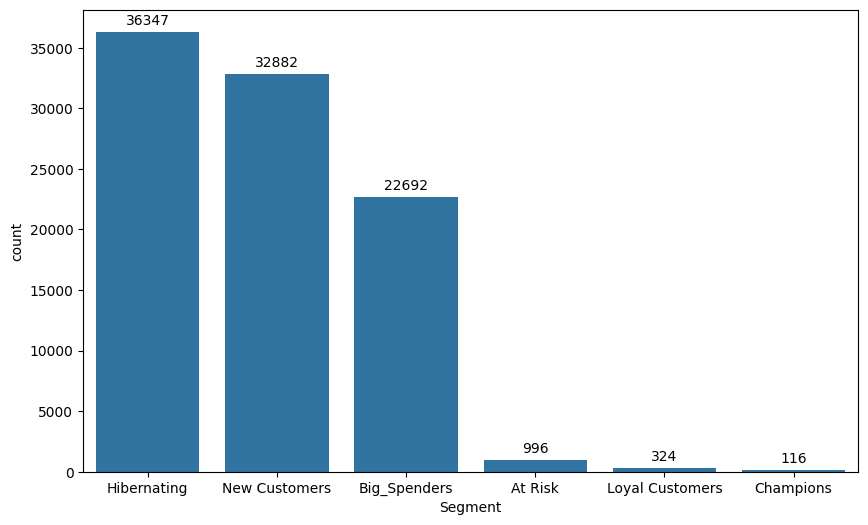

In [127]:
segment_order = rfm['Segment'].value_counts().index
plt.figure(figsize=(10,6))
ax=sns.countplot(data=rfm, x='Segment', order=segment_order)
for container in ax.containers:
    ax.bar_label(container, padding=3)

###### Champions → give loyalty rewards <br> At Risk → send win-back campaign <br> Hibernating → low priority marketing <br> Big spenders → premium offers

<Axes: xlabel='R_score', ylabel='F_score'>

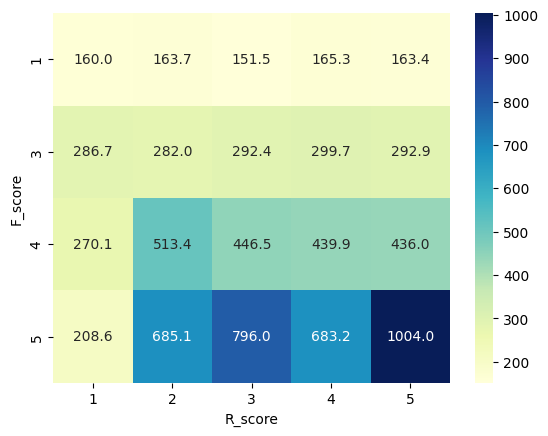

In [128]:
rfm_matrix = rfm.pivot_table(index='F_score',
                             columns='R_score',
                             values = 'Monetary',
                             aggfunc = 'mean')
sns.heatmap(rfm_matrix, annot=True, fmt=".1f", cmap="YlGnBu")


In [129]:
# cohort analysis

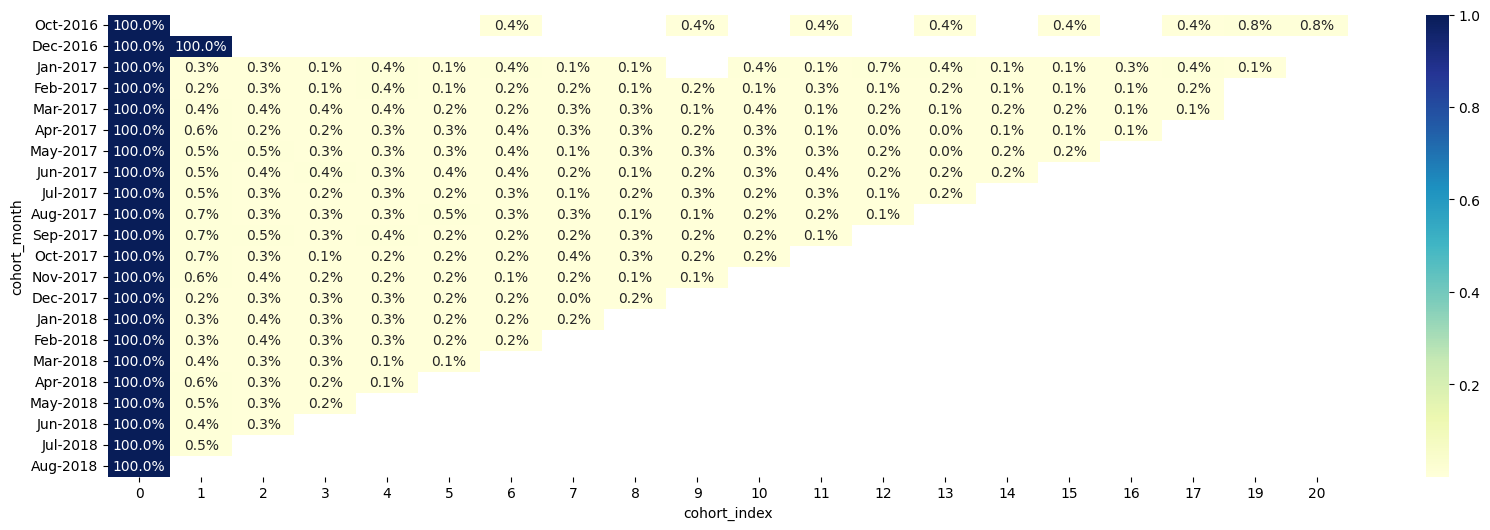

In [130]:
df['order_month']= df['order_purchase_timestamp'].dt.to_period('M')
df['cohort_month']= df.groupby('customer_unique_id')['order_month'].transform('min')
cohort = df.groupby(['cohort_month','order_month']).agg({
    'customer_unique_id' : 'nunique',
    'order_id' : 'nunique',
    'payment_value' : 'sum',
}).reset_index()
cohort['cohort_index'] = (cohort['order_month'] - cohort['cohort_month']).apply(lambda x : x.n)
cohort
cohort_matrix = cohort.pivot_table(
    index='cohort_month',
    columns = 'cohort_index',
    values = 'customer_unique_id'
    )
cohort_matrix=cohort_matrix.divide(cohort_matrix.iloc[:, 0], axis=0)
plot_matrix = cohort_matrix.copy()
plot_matrix.index = plot_matrix.index.strftime( "%b-%Y")
# cohort_matrix = cohort_matrix.fillna(0)
plt.figure(figsize=(20,6))
sns.heatmap(plot_matrix, annot = True, cmap="YlGnBu", fmt=".1%")
plt.show()

In [ ]:
# df[['customer_unique_id','order_id']].value_counts()
# rfm[rfm['Frequency']>5]


In [132]:
df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'order_month', 'cohort_month'],
      dtype='object')